In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
from matplotlib.colors import LinearSegmentedColormap

In [2]:
csv_path = "/Users/martina/Università/esami_da_fare/complex_networks/sea-duck-network/centroids_k28_definitivo.csv"

df_full = pd.read_csv(csv_path, sep=';')

df_full.head()

df = df_full[df_full['species'] == 'BLSC'].copy()

   Progresso: 5/21 nodi...
   Progresso: 10/21 nodi...
   Progresso: 15/21 nodi...
   Progresso: 20/21 nodi...


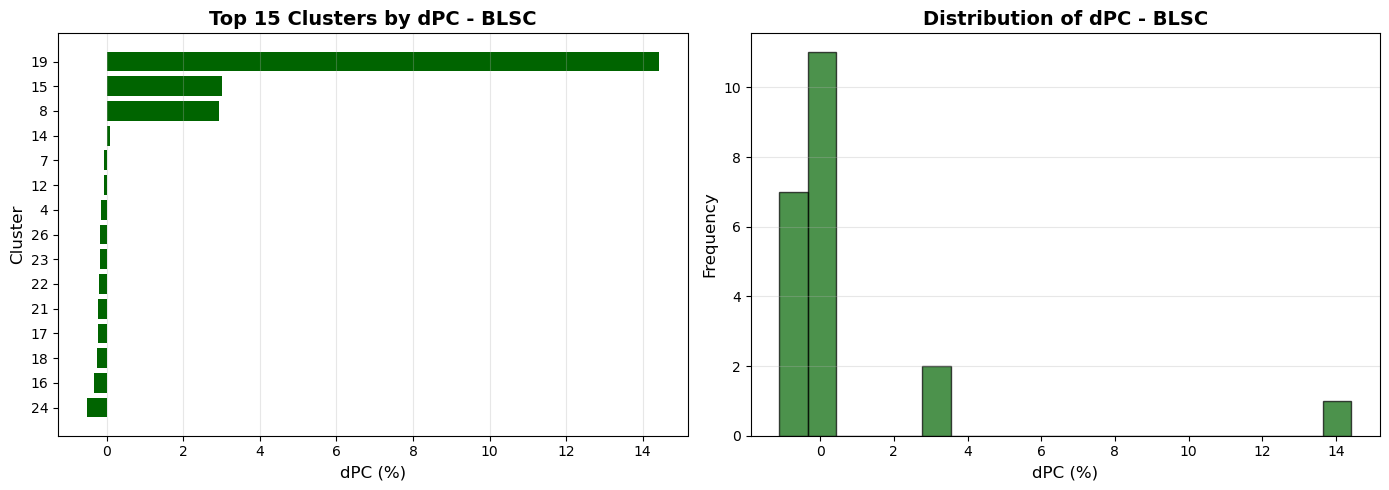

In [ ]:
def calculate_dPC(df, alpha=0.5):
  
    df_valid = df[df['next_cluster'].notna()].copy()
    df_valid['next_cluster'] = df_valid['next_cluster'].astype(int)
 
    node_weights = df.groupby('cluster')['wt_sp'].sum().to_dict()
  
    edge_weights = df_valid.groupby(['cluster', 'next_cluster'])['wt_sp'].sum().reset_index()
    edge_weights.columns = ['source', 'target', 'weight']
    
    G = nx.DiGraph()
    
    for node, weight in node_weights.items():
        G.add_node(node, weight=weight)
    

    for _, row in edge_weights.iterrows():
        weight = row['weight']
        distance = 1.0 / (weight ** alpha)  
        G.add_edge(int(row['source']), int(row['target']), 
                   weight=weight, distance=distance)
    
  
    PC_total = calculate_PC(G, alpha)
   
    dpc_results = []
    nodes = list(G.nodes())
    
    for i, node in enumerate(nodes):
        if (i + 1) % 5 == 0:
            print(f"   Progresso: {i+1}/{len(nodes)} nodi...")
        
        # Crea grafo senza il nodo k
        G_without_k = G.copy()
        G_without_k.remove_node(node)
        
        # Ricalcola PC senza il nodo k
        PC_without_k = calculate_PC(G_without_k, alpha)
        
        # Calcola dPC (in percentuale)
        if PC_total > 0:
            dPC = ((PC_total - PC_without_k)/PC_total) * 100
        else:
            dPC = 0
        
        dpc_results.append({
            'cluster': node,
            'dPC': dPC,
            'PC_without': PC_without_k
        })
    
    dpc_df = pd.DataFrame(dpc_results).sort_values('dPC', ascending=False)
    
    
    return dpc_df, G


def calculate_PC(G, alpha):
    
    if G.number_of_nodes() == 0:
        return 0.0
    
    # Pesi dei nodi
    nodes = list(G.nodes())
    node_weights = {node: G.nodes[node].get('weight', 1) for node in nodes}
    
    # A_L = somma totale dei pesi
    A_L = sum(node_weights.values())
    
    if A_L == 0:
        return 0.0
    
    try:
        all_paths = dict(nx.all_pairs_dijkstra_path_length(G, weight='distance'))
    except:
        all_paths = {}
    
    # Calcola PC
    PC = 0.0
    
    for i in nodes:
        for j in nodes:
            if i == j:
                p_ij_star = 1.0
            else:
              
                if i in all_paths and j in all_paths[i]:
                
                    dist_ij = all_paths[i][j]
                    # Probabilità di connessione: exp(-distanza)
                    p_ij_star = np.exp(-dist_ij)
                else:
                    # Nodi non connessi
                    p_ij_star = 0.0
            
            # Contributo al PC
            a_i = node_weights[i]
            a_j = node_weights[j]
            PC += a_i * a_j * p_ij_star
    
    # Normalizza per A_L^2
    PC = PC / (A_L ** 2)
    
    return PC


def plot_dPC_results(dpc_df):
  
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1 = axes[0]
    top_dpc = dpc_df.head(15)
    ax1.barh(top_dpc['cluster'].astype(str), top_dpc['dPC'], color='darkgreen')
    ax1.set_xlabel('dPC (%)', fontsize=12)
    ax1.set_ylabel('Cluster', fontsize=12)
    ax1.set_title('Top 15 Clusters by dPC - BLSC', fontsize=14, fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)
    
    ax2 = axes[1]
    ax2.hist(dpc_df['dPC'], bins=20, edgecolor='black', alpha=0.7, color='darkgreen')
    ax2.set_xlabel('dPC (%)', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.set_title('Distribution of dPC - BLSC', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()


dpc_df, G = calculate_dPC(df, alpha=0.5)

plot_dPC_results(dpc_df)


📊 Range dPC: -1.12% to 14.42%
   Negativi: 17 cluster
   Positivi: 4 cluster


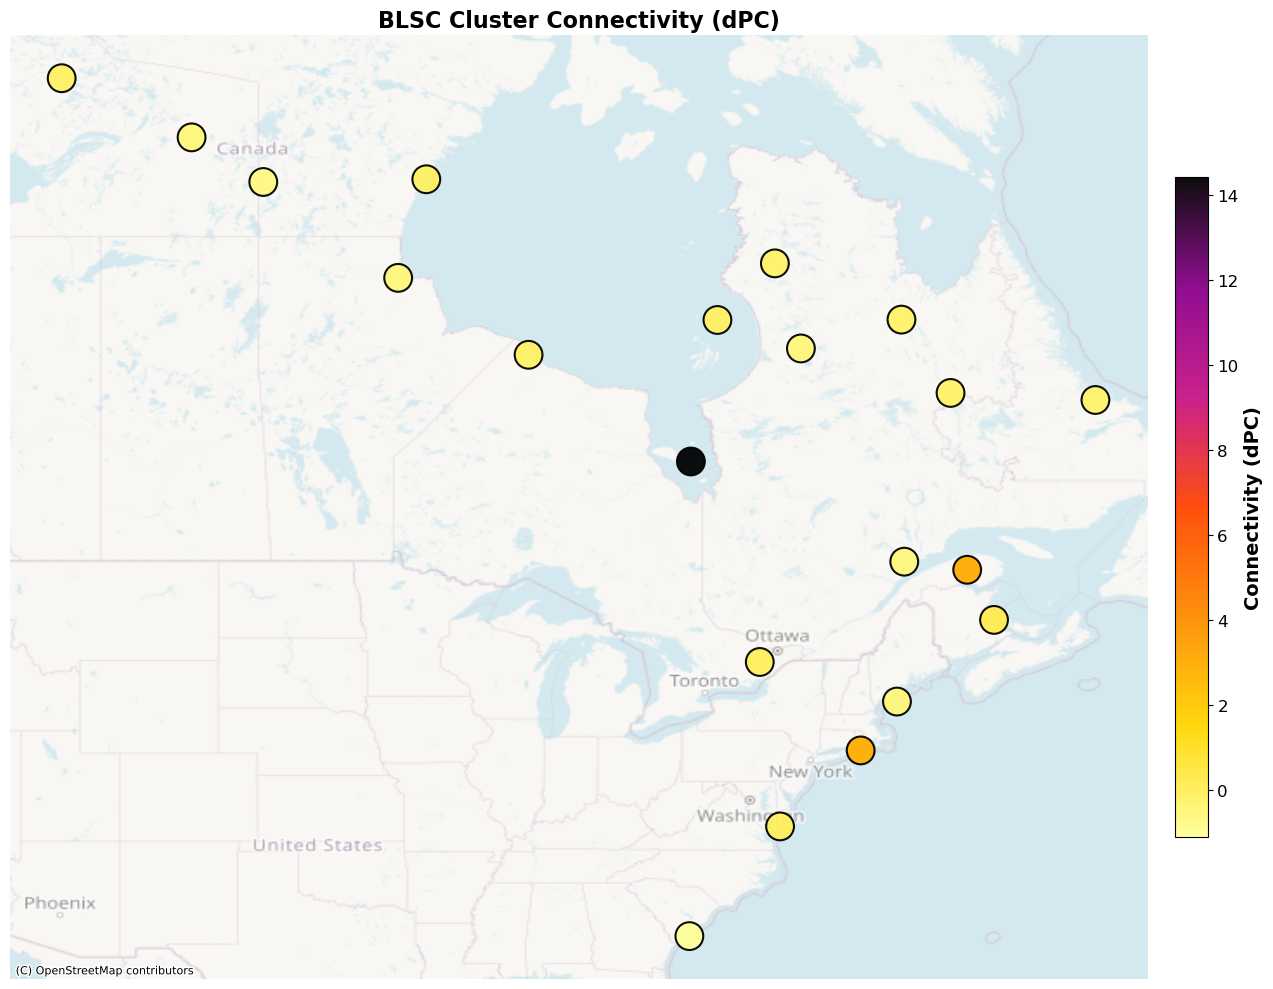

In [5]:
def plot_dPC_map(df, dpc_df):
  
    cluster_coords = df.groupby('cluster').agg({
        'lat': 'mean',
        'lon': 'mean'
    }).reset_index()
    
    cluster_data = cluster_coords.merge(dpc_df, on='cluster')
    
    def lat_lon_to_web_mercator(lon, lat):
    
        x = lon * 20037508.34 / 180
        y = np.log(np.tan((90 + lat) * np.pi / 360)) / (np.pi / 180)
        y = y * 20037508.34 / 180
        return x, y
    
    x_coords = []
    y_coords = []
    for _, row in cluster_data.iterrows():
        x, y = lat_lon_to_web_mercator(row['lon'], row['lat'])
        x_coords.append(x)
        y_coords.append(y)
    
    cluster_data['x_web'] = x_coords
    cluster_data['y_web'] = y_coords
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    colors = ['#FFFF99', '#FFD700', '#FF8C00', '#FF4500', '#C71585', '#8B008B', '#000000']
    cmap = LinearSegmentedColormap.from_list('dpc', colors, N=256)
    
    dpc_percent = cluster_data['dPC']
    
    vmin = min(0, dpc_percent.min())
    vmax = max(5, dpc_percent.max())  
    
    print(f"\n📊 Range dPC: {vmin:.2f}% to {vmax:.2f}%")
    print(f"   Negativi: {(dpc_percent < 0).sum()} cluster")
    print(f"   Positivi: {(dpc_percent >= 0).sum()} cluster")
    
    scatter = ax.scatter(
        cluster_data['x_web'],
        cluster_data['y_web'],
        c=dpc_percent,
        s=400,
        cmap=cmap,
        vmin=vmin, 
        vmax=vmax,
        edgecolors='black',
        linewidths=1.5,
        zorder=10,
        alpha=0.95
    )
    
    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5, zorder=1)
  
    cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', 
                        pad=0.02, shrink=0.7, aspect=20)
    cbar.set_label('Connectivity (dPC)', fontsize=14, fontweight='bold')
    cbar.ax.tick_params(labelsize=12)
    ax.set_title('BLSC Cluster Connectivity (dPC)', fontsize=16, fontweight='bold')

    ax.set_axis_off()
    
    plt.tight_layout()
    plt.show()
    
    
plot_dPC_map(df, dpc_df)